# Constraining Hubble Constant ($H_0$) and Density Parameter ($\Omega_m$) Using Supernovae (Type la) from Pantheon+SH0ES: A Hubble Diagram Analysis

### Objective  
The main objective of this project is to estimate key cosmological parameters using observational data from Type Ia supernovae, based on the Pantheon+SH0ES dataset. In particular, this analysis aims to determine the value of the Hubble constant ($H_0$) and the matter density parameter ($\Omega$)  by fitting the distance modulus–redshift relation, also known as the Hubble diagram. This project also investigates how fixing $\Omega$ affects the fitted value of $H_0$, and it explores the age of the Universe as derived from the best-fit parameters. Additionally, the quality of the cosmological fit is assessed by analyzing residuals, and the data is split into low-redshift and high-redshift subsets to study any redshift-dependent differences in $H_0$. These results are compared with the Planck 2018 measurements to discuss the current status of the so-called Hubble tension.

### Dataset Description  
This project uses the Pantheon+SH0ES dataset, which is one of the most comprehensive compilations of Type Ia supernova observations currently available. The dataset includes measurements from the original Pantheon sample, combined with the latest calibrations from the SH0ES (Supernovae, H₀, for the Equation of State) project. In total, it provides precise redshift and photometric data for over 1,500 Type Ia supernovae, covering a wide redshift range from $z$ ~ 0.001 to $ z > 1$.  

We specifically use the following parameters from the dataset:  
- `zHD` : Redshift values used for plotting the Hubble diagram (based on heliocentric corrections)  
- `MU_SH0ES` : SH0ES-calibrated distance modulus values (with an anchored absolute magnitude)  
- `MU_SH0ES_ERR_DIAG` : Associated diagonal uncertainties in the distance modulus  

These variables are directly suitable for cosmological parameter fitting, as they avoid the need for an independent calibration of the supernova absolute magnitude. The SH0ES calibration provides a direct link to the local distance ladder, which enables us to estimate the absolute value of the Hubble constant $H_0$.

### Data Cleaning & Preprocessing

#### Libraries Calling:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.constants import c
from astropy import units as u
import matplotlib.cm as cm
from matplotlib.colors import Normalize

#### Load the Pantheon+SH0ES dataset

In [3]:
# Local file path
file_path = r"/content/2_Pantheon+SH0ES.dat" # "path_to_your_file" and r used to handle backslashes in Windows paths

# Load the file
file = pd.read_csv(file_path, delim_whitespace=True, comment='#') # here we assume the file is whitespace-delimited and has comments starting with '#'

# See structure
file.info() # Display the structure of the DataFrame


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15  c                    

/tmp/ipython-input-3-1204697593.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  file = pd.read_csv(file_path, delim_whitespace=True, comment='#') # here we assume the file is whitespace-delimited and has comments starting with '#'


In [4]:
# Preview Dataset Columns
print(file.columns)  # Print the column names to understand the structure

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')


In [5]:
# Preview the first few rows of the DataFrame
file.head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


#### Cleaning and Extracting Relevant Data

In [7]:
# Filter for entries with usable data based on the required columns
clean_file = file.dropna(subset=['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG'])
# Extract these cleaned columns as numpy arrays
z = clean_file['zHD'].values # redshift of Hubble Diagram
mu = clean_file['MU_SH0ES'].values # distance modulus
mu_err = clean_file['MU_SH0ES_ERR_DIAG'].values # uncertainty in distance modulus
print("redshift (z) :",z, "\ndistance modulus (mu) :",mu, "\nuncertainty in distance modulus (mu_err):" ,mu_err)  # Print the arrays to verify their contents

redshift (z) : [1.22000e-03 1.22000e-03 2.56000e-03 ... 1.80119e+00 1.91165e+00
 2.26137e+00] 
distance modulus (mu) : [28.9987 29.0559 30.7233 ... 45.4865 45.4233 46.1828] 
uncertainty in distance modulus (mu_err): [1.51645  1.51747  0.782372 ... 0.281981 0.358642 0.281309]


### Exploratory Data Analysis (EDA)

#### Redshift Disribution

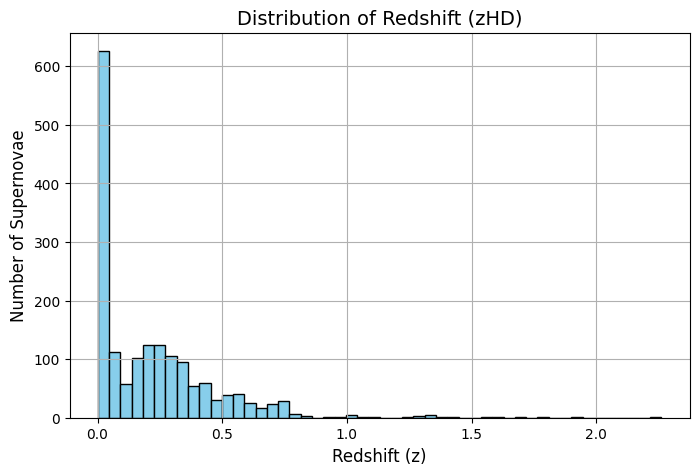

In [10]:
plt.figure(figsize=(8, 5))
Bin = int(np.ceil(1 + np.log2(len(z))))  # # Sturges's rule, n: no. of data points
plt.hist(z, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Redshift (z)", fontsize=12)
plt.ylabel("Number of Supernovae", fontsize=12)
plt.title("Distribution of Redshift (zHD)", fontsize=14)
plt.grid(True)
plt.show()


#### Plot of Hubble diagram  
Let’s visualize the relationship between redshift $z$ and distance modulus $\mu$, known as the Hubble diagram. This plot is a cornerstone of observational cosmology—it allows us to compare supernova observations with theoretical predictions based on different cosmological models.

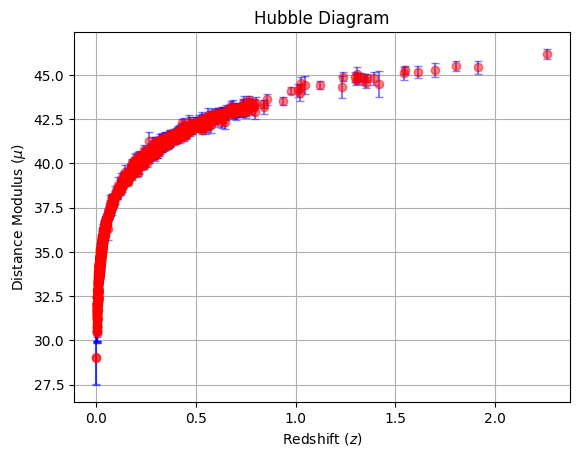

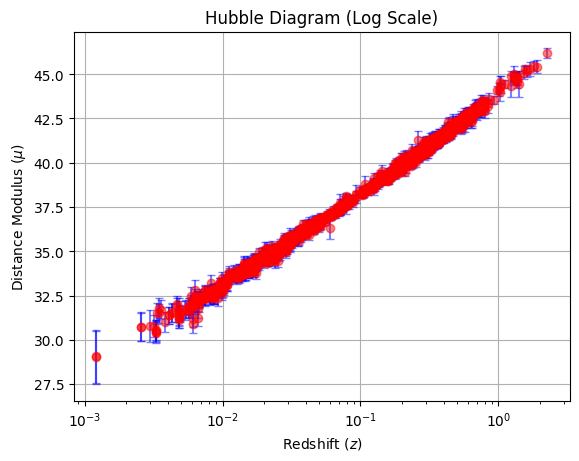

In [11]:
# Plot the distance modulus and the redshift (x-axis), label them accordingly.
plt.figure()  # Create a new figure with a specific name
plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='red', ecolor='blue', capsize=3, label= 'Data', alpha=0.5) # yerr= error bar, fmt='o' for circle markers, color for marker color, ecolor for error bar color, capsize for the size of the error bar caps
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.title('Hubble Diagram') # Distance Modulus vs Redshift
plt.show()

# Using log scale in x-axis
plt.figure()
plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='red', ecolor='blue', capsize=3, label='Data', alpha=0.5)  # Data points with error bars
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.title('Hubble Diagram (Log Scale)')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.show()


### Modeling & Analysis

#### The Cosmological Model

We now define the theoretical framework based on the flat $\Lambda\mathrm{CDM}$ model (read about the model in wikipedia if needed). This involves:

- The dimensionless Hubble parameter:
  $$
  E(z) = \sqrt{\Omega_m (1+z)^3 + (1 - \Omega_m)}
  $$

- The distance modulus is:
  $$
  \mu(z) = 5 \log_{10}(d_L / \text{Mpc}) + 25
  $$

- And the corresponding luminosity distance :
  
  $$
  d_L(z) = (1 + z) \cdot \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}
  $$

These equations allow us to compute the expected distance modulus from a given redshift $z$, Hubble constant $H_0$, and matter density parameter $\Omega_m$.


In [12]:
# Define the E(z) for flat LCDM
def E(z1, Omega_m1): # Here, we use z1 not to confuse with z which is the redshift array. z1 is just local variable for function. Similarly, Omega_m1.
    return np.sqrt(Omega_m1 * (1 + z1)**3 + (1 - Omega_m1))

# Luminosity distance in Mpc, try using scipy quad to integrate.
def luminosity_distance(z1, H0_1, Omega_m1): # Here, we use z1 not to confuse with z which is the redshift array
    # Convert unit of H0 to SI units (km/s/Mpc to 1/s). But inside the function we use H0_1 as a local variable or constant w.r.t. the function.
    H0_SI = H0_1*(1/ 3.086e19)  # H0 in s^-1 (1 Mpc = 3.086e19 km)
    #  Calculate the luminosity distance using the integral of E(z)
    d_L = np.array([(1+zi)* (c.value / H0_SI) *quad(lambda z_prime: 1 / E(z_prime, Omega_m1), 0, zi)[0] for zi in z1])
    # lambda is anonymous function we need just once.So z_prime is dummy variable for integration.
    # c.value is the speed of light in m/s, we need to convert it to Mpc
    return d_L / 3.086e22  # Convert from meters to Mpc

# Theoretical distance modulus, use above function inside mu_theory to compute luminosity distance
def mu_theory(z1, H0_1, Omega_m1):
    D_L= luminosity_distance(z1, H0_1, Omega_m1)
    return 5 * np.log10(D_L) + 25  # Distance modulus formula


#### Fitting the Model to Supernova Data

We now perform a non-linear least squares fit to the supernova data using our theoretical model for $\mu(z)$. This fitting procedure will estimate the best-fit values for the Hubble constant $ H_0$ and matter density parameter $\Omega_m$, along with their associated uncertainties.

We'll use:
- `curve_fit` from `scipy.optimize` for the fitting.
- The observed distance modulus \(\mu\), redshift \(z\), and measurement errors.

The initial guess is:
- $ H_0 = 70 \, \text{km/s/Mpc} $
- $\Omega_m =0.3$

In [13]:
# Initial guess: H0 = 70, Omega_m = 0.3
p0 = [70,  0.3]

# This wrapper function is used because curve_fit calls parameter internally. If, we use mu_theory directly, it may not unpack the parameters correctly as mu_theory works well when we call it manually (H0= 70, Omega_m= 0.3).
def mu_model(z1, H0_1, Omega_m1):
    """
    Model function for distance modulus based on Hubble's law.
    """
    return mu_theory(z1, H0_1, Omega_m1)

# Fit the model to the data using curve_fit
# General format: parameters optimal, parameter covariance = curve_fit(function, xdata, ydata, p0=initial_guess, sigma=errors, absolute_sigma=True)
params, covariance = curve_fit(mu_model, z, mu, p0=p0, sigma=mu_err, absolute_sigma=True)
# function: mu_theory, xdata: z, ydata: mu, p0: initial guess, sigma: mu_err, absolute_sigma: True

# Extract fitted parameters and their uncertainties
H0_fit, Omega_m_fit = params # unpack the parameters
H0_err, Omega_m_err = np.sqrt(np.diag(covariance))  # Extract errors from the covariance matrix

# Print the fitted parameters and their uncertainties
print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} (km/s)/Mpc")
print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")

# Write a code for fitting and taking error out of the parameters
#print(f"Fitted H0 = {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
#print(f"Fitted Omega_m = {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")


Fitted H0 = 72.97 ± 0.26 (km/s)/Mpc
Fitted Omega_m = 0.351 ± 0.019


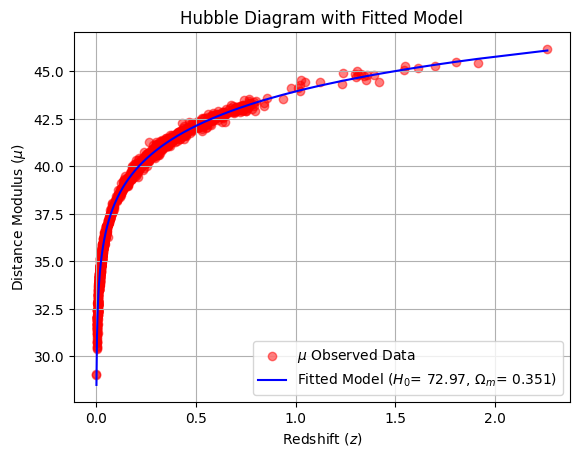

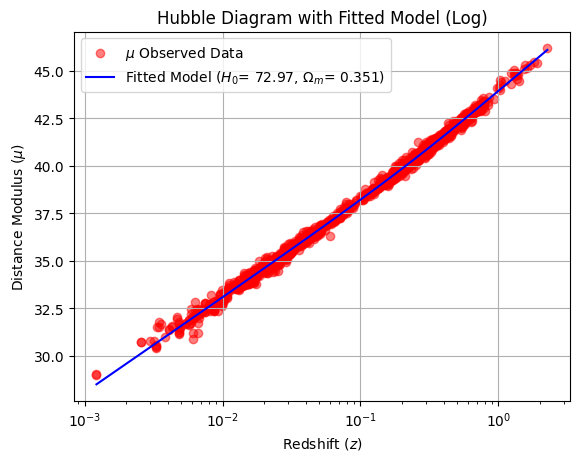

In [15]:
# Plot the Hubble diagram with the fitted model

mu_theory_fit_values = mu_theory(z, H0_fit, Omega_m_fit)  # Calculate the theoretical distance modulus using the fitted parameters

plt.figure()
##plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='green', ecolor='red', capsize=3, label='Data', alpha=0.4)  # Data points with error bars
plt.scatter(z, mu, color='red', label= '$\mu$ Observed Data', alpha=0.5)
plt.plot(z, mu_theory_fit_values, color='blue', label='Fitted Model ($H_0$= 72.97, $\Omega_m$= 0.351)')  # Fitted model line
plt.title('Hubble Diagram with Fitted Model')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.legend()
plt.grid(True)
plt.show()


plt.figure()
##plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='green', ecolor='red', capsize=3, label='Data', alpha=0.4)  # Data points with error bars
plt.scatter(z, mu, color='red', label= '$\mu$ Observed Data', alpha=0.5)
plt.plot(z, mu_theory_fit_values, color='blue', label='Fitted Model ($H_0$= 72.97, $\Omega_m$= 0.351)')  # Fitted model line
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.title('Hubble Diagram with Fitted Model (Log)')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.legend()
plt.grid(True)
plt.show()

#### Estimating the Age of the Universe

Now that we have the best-fit values of $ H_0 $ and $ \Omega_m $, we can estimate the age of the universe. This is done by integrating the inverse of the Hubble parameter over redshift:

$$
t_0 = \int_0^\infty \frac{1}{(1 + z) H(z)} \, dz
$$

We convert $ H_0 $ to SI units and express the result in gigayears (Gyr). This provides an independent check on our cosmological model by comparing the estimated age to values from other probes like Planck CMB measurements.

In [16]:
# Write the function for age of the universe as above

def H_z(z1, H0_1, Omega_m1):
    """
    Hubble parameter as a function of redshift.
    """
    return H0_1 * np.sqrt(Omega_m1 * (1 + z1)**3 + (1 - Omega_m1))

def integrand(z1, H0_1, Omega_m1):
    """
    Integrand for the age of the universe calculation.
    """
    return 1 / ((1 + z1) * H_z(z1, H0_1, Omega_m1))

def age_of_universe(H0_1, Omega_m1):

    ##H0_SI =  H0_1 * (u.km / u.s / u.Mpc)  # Convert H0 to SI units (1 Mpc = 3.086e19 km)
    ##H0_Value_SI = H0_SI.to(u.s**-1)  #  Convert H0 to s^-1
    ##integral_result, integral_error =quad( 1 / ((1 + z1) * H_z(z1, H0_1, Omega_m1)), 0, 1000, args=(H0_1, Omega_m1))

    integral_result, integral_error = quad(integrand, 0, 1000, args=(H0_1, Omega_m1))
    # Here, z is not the clean data zHD (values from the dataset), but a variable representing redshift in the integral.
    # quad is used to perform numerical integration, args is used to pass additional parameters to the function.
    # 0 to 1000 is limit of integration. Practically, we can take it to infinity, but for numerical stability, we limit it to a large value.

    ##t0_sec = integral_result / H0_Value_SI  # Time in seconds

    t0_sec = integral_result * (u.Mpc / (u.km / u.s))  # Quantity in seconds
    t0_gyr = ((t0_sec).to(u.Gyr)).value  # Convert seconds to Gyr
    return  t0_gyr # in Gyr

t0 = age_of_universe(H0_fit, Omega_m_fit)  # Calculate the age of the universe using the fitted parameters
print(f"Estimated age of Universe: {t0:.2f} Gyr")

t0_fixOm = age_of_universe(H0_fit, 0.3)  # Calculate the age of the universe using the fitted H0 and fixed Omega_m = 0.3.
print(f"Estimated age of Universe with fixed Omega_m(0.3) : {t0_fixOm:.2f} Gyr")


Estimated age of Universe: 12.36 Gyr
Estimated age of Universe with fixed Omega_m(0.3) : 12.92 Gyr


#### Analyze Residuals

To evaluate how well our cosmological model fits the data, we compute the residuals:

$$
\text{Residual} = \mu_{\text{obs}} - \mu_{\text{model}}
$$

Plotting these residuals against redshift helps identify any systematic trends, biases, or outliers. A good model fit should show residuals scattered randomly around zero without any significant structure.

In [17]:
# Write the code to find residual by computing mu_theory and then plot
# We have already defined mu_theory function above, so we can use it directly to compute the theoretical distance modulus.
mu_model_values = mu_theory(z, H0_fit, Omega_m_fit)  # Compute the theoretical distance modulus using the fitted parameters
# As we have defined mu as clean_file['MU_SH0ES'].values, we can use it directly to compute the residuals.
residuals = mu - mu_model_values  # Calculate the residuals (observed - model)
print("Residuals:", residuals)  # Print the residuals to verify their contents
print("Maximum Value of Residuals:",max(residuals), "\nMinimum Value of Residuals:", min(residuals))  # Print the maximum and minimum residuals to check the range

res_close_to_0_positive = min(residuals[residuals > 0])  # Find the minimum positive residual close to zero
res_close_to_0_negative = max(residuals[residuals < 0])  # Find the maximum negative residual close to zero
res_close_0 =[res_close_to_0_positive, res_close_to_0_negative]  # List of minimum positive and maximum negative residuals close to zero
print("Minimum positive residual close to zero:", res_close_to_0_positive, "\nMaximum negative residual close to zero:", res_close_to_0_negative)  # Print the minimum positive and maximum negative residuals close to zero

Residuals: [ 0.4966969   0.5538969   0.60975833 ... -0.01585177 -0.23554964
  0.08369463]
Maximum Value of Residuals: 1.0053498590850758 
Minimum Value of Residuals: -1.1180670932415033
Minimum positive residual close to zero: 0.00014674732675246105 
Maximum negative residual close to zero: -5.522360979171026e-06


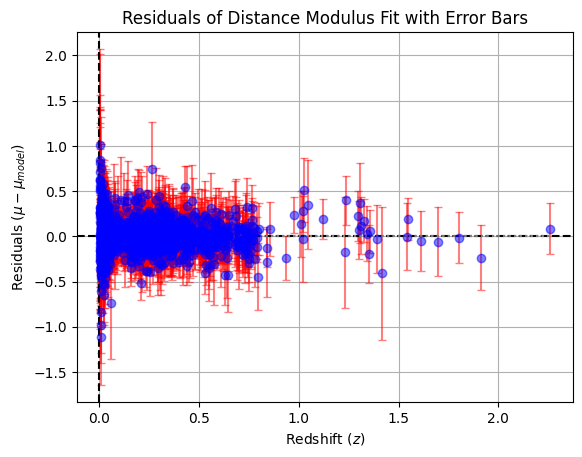

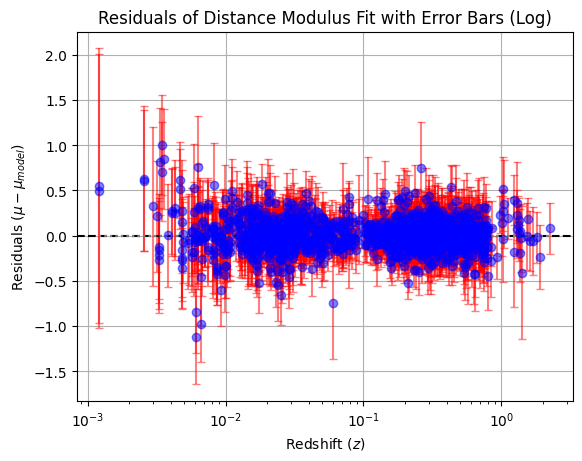

In [18]:
# Plot the residuals against redshift
plt.figure()
plt.errorbar(z, residuals, yerr=mu_err, fmt='o', color='blue', ecolor='red', capsize=3, alpha=0.5)  # Plot residuals with error bars
##plt.plot(z, residuals, color='Red', label='Residuals Vs Redshift')  # Plot residuals as points
plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at zero for reference
plt.axvline(0, color='black', linestyle='--')  # Add a vertical line at zero for reference
plt.hlines(res_close_0, min(z), max(z), colors= 'gray', linestyles=':')  # Add horizontal lines at the minimum positive and maximum negative residuals close to zero
plt.title('Residuals of Distance Modulus Fit with Error Bars')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Residuals ($\mu - \mu_{model}$)")
plt.grid(True)
##plt.legend()
plt.show()

plt.figure()
plt.errorbar(z, residuals, yerr=mu_err, fmt='o', color='blue', ecolor='red', capsize=3, alpha=0.5)  # Plot residuals with error bars
##plt.plot(z, residuals, color='Red', label='Residuals Vs Redshift')  # Plot residuals as points
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at zero for reference
##plt.axvline(0, color='black', linestyle='--')  # Add a vertical line at zero for reference
plt.hlines(res_close_0, min(z), max(z), colors= 'gray', linestyles=':')  # Add horizontal lines at the minimum positive and maximum negative residuals close to zero
plt.title('Residuals of Distance Modulus Fit with Error Bars (Log)')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Residuals ($\mu - \mu_{model}$)")
plt.grid(True)
##plt.legend()
plt.show()


#### **Fitting** with Fixed Matter Density

To reduce parameter degeneracy, let's fix $ \Omega_m = 0.3 $ and fit only for the Hubble constant $ H_0 $.

In [19]:
# Initial guess for fitting with fixed Omega_m, H0 = 70.
p1 = [70]  # Only H0, Omega_m is fixed at 0.3

def mu_fixed_Om(z1, H0_1):  # This function will use the fixed Omega_m value. And this is wrapper function for mu_theory.
    return mu_theory(z1, H0_1, 0.3)

# Fit the model with fixed Omega_m
params_fixed_Om, covariance_fixed_Om = curve_fit(mu_fixed_Om, z, mu, p0=p1, sigma=mu_err, absolute_sigma=True)

H0_fit_fixOm = params_fixed_Om[0]  # Extract the fitted H0 value
H0_err_fixOm = np.sqrt(covariance_fixed_Om[0][0])  # Extract the error from the covariance matrix
# Try fitting with this fixed value

print(f"Fitted H0 with fixed Omega_m = {H0_fit_fixOm:.2f} (km/s)/Mpc")

Fitted H0 with fixed Omega_m = 73.53 (km/s)/Mpc


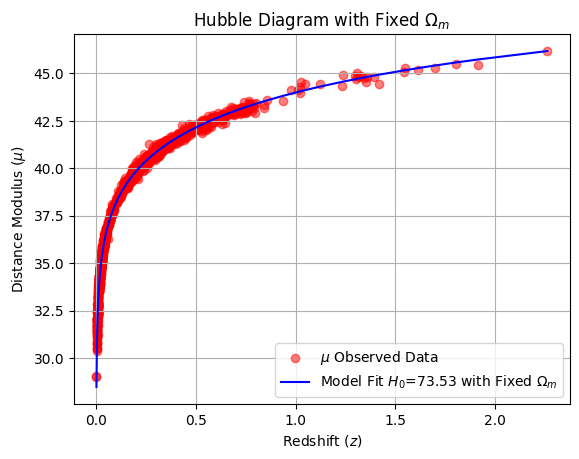

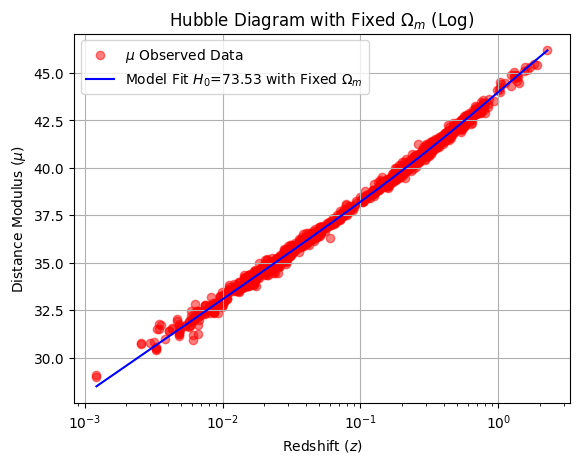

In [20]:
# Lets plot the model with fixed Omega_m
mu_model_values_fixed_Om = mu_fixed_Om(z, H0_fit_fixOm)  # Compute the theoretical distance modulus using the fitted H0 with fixed Omega_m

plt.figure()
##plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='red', ecolor='green', capsize=3, label= '$\mu$ Observed Data', alpha=0.5)  # Plot the data with error bars
plt.scatter(z, mu, color='red', label= '$\mu$ Observed Data', alpha=0.5)
plt.plot(z, mu_model_values_fixed_Om, color='blue', label='Model Fit $H_0$=73.53 with Fixed $\Omega_m$')  # Plot the model with fixed Omega_m
plt.title('Hubble Diagram with Fixed $\Omega_m$')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
##plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='red', ecolor='green', capsize=3, label= '$\mu$ Observed Data', alpha=0.5)  # Plot the data with error bars
plt.scatter(z, mu, color='red', label= '$\mu$ Observed Data', alpha=0.5)
plt.plot(z, mu_model_values_fixed_Om, color='blue', label='Model Fit $H_0$=73.53 with Fixed $\Omega_m$')  # Plot the model with fixed Omega_m
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.title('Hubble Diagram with Fixed $\Omega_m$ (Log)')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.legend()
plt.show()

#### Comparing Low-z and High-z Subsamples

Finally, we examine whether the inferred value of $H_0$ changes with redshift by splitting the dataset into:
- **Low-z** supernovae ($ z < 0.1 $)
- **High-z** supernovae ($ z \geq 0.1 $)

We then fit each subset separately (keeping $ \Omega_m = 0.3 $) to explore any potential tension or trend with redshift.

In [21]:
# We alredy have wrapper function for mu_theory for fixed Omega_m, i.e, mu_fixed_Om.

# Split the data for the three columns and do the fitting again and see
z_split = 0.1  # The split point for low-z and high-z data

# For Low-z supernovae
mask_low = z < z_split
z_low = z[mask_low]
mu_low = mu[mask_low]
mu_err_low = mu_err[mask_low]
# Fit for low-z data with initial guess H0 = 70 with fixed Omega_m.
p2 = [70]  # Initial guess for H0
params_low_fix_Om, covariance_low_fix_Om = curve_fit(mu_fixed_Om, z_low, mu_low, p0=p2, sigma=mu_err_low, absolute_sigma=True)
H0_low_fit_fixOm = params_low_fix_Om[0]  # Extract the fitted H0 value for low-z
H0_err_low_fit_fixOm = np.sqrt(covariance_low_fix_Om[0][0])

# For High-z supernovae
mask_high = z >= z_split
z_high = z[mask_high]
mu_high = mu[mask_high]
mu_err_high = mu_err[mask_high]
# Fit for high-z data with initial guess H0 = 70 with fixed Omega_m.
p3 = [70]  # Initial guess for H0
params_high_fix_Om, covariance_high_fix_Om = curve_fit(mu_fixed_Om, z_high, mu_high, p0=p3, sigma=mu_err_high, absolute_sigma=True)
H0_high_fit_fixOm = params_high_fix_Om[0]  # Extract the fitted H0 value for high-z
H0_err_high_fit_fixOm = np.sqrt(covariance_high_fix_Om[0][0])

print(f"Low-z (z < {z_split}): H₀ = {H0_low_fit_fixOm:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}): H₀ = {H0_high_fit_fixOm:.2f} km/s/Mpc")


Low-z (z < 0.1): H₀ = 73.01 km/s/Mpc
High-z (z ≥ 0.1): H₀ = 73.85 km/s/Mpc


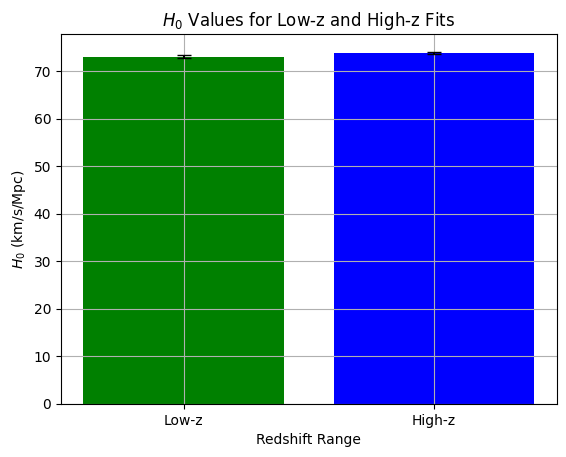

In [24]:
# Histogram of H0 values for low-z and high-z fits
plt.figure()
plt.bar(['Low-z', 'High-z'], [H0_low_fit_fixOm, H0_high_fit_fixOm], yerr=[H0_err_low_fit_fixOm, H0_err_high_fit_fixOm], capsize=5, color=['green', 'blue'])
plt.title('$H_0$ Values for Low-z and High-z Fits')
plt.xlabel('Redshift Range')
plt.ylabel('$H_0$ (km/s/Mpc)')
plt.grid(True)
plt.show()

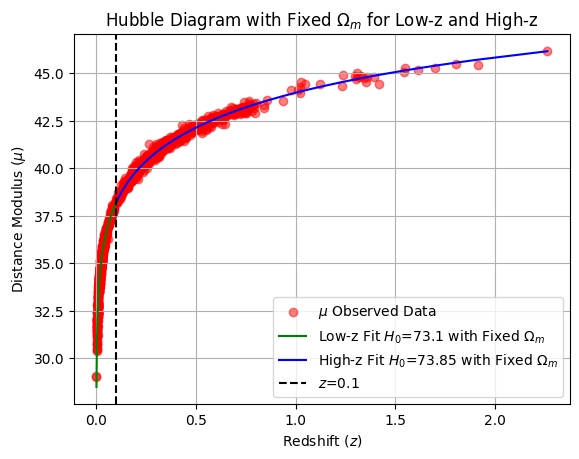

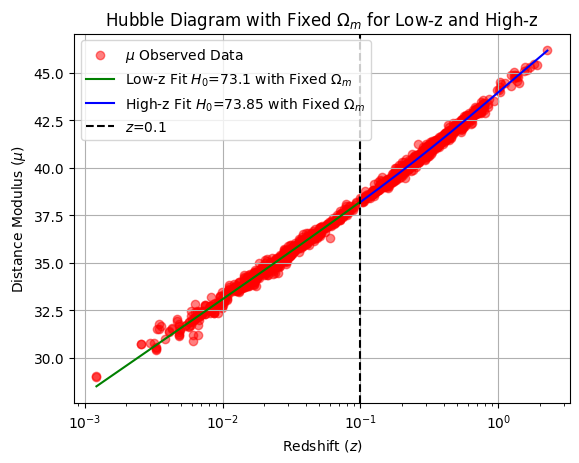

In [22]:
# Plot the Hubble Diagram with fixed Omega_m for low-z and high-z data

mu_model_values_low_fixOm = mu_fixed_Om(z_low, H0_low_fit_fixOm)  # Compute the theoretical distance modulus for low-z
mu_model_values_high_fixOm = mu_fixed_Om(z_high, H0_high_fit_fixOm)  # Compute the theoretical distance modulus for high-z

plt.figure()
#plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='orange', ecolor='red', capsize=3, label='$\mu$ Observed Data', alpha=0.4)  # Plot the data with error bars
plt.scatter(z, mu, color='red', label='$\mu$ Observed Data', alpha=0.5)
plt.plot(z_low, mu_model_values_low_fixOm, color='green', label='Low-z Fit $H_0$=73.1 with Fixed $\Omega_m$')  # Plot the low-z model
plt.plot(z_high, mu_model_values_high_fixOm, color='blue', label='High-z Fit $H_0$=73.85 with Fixed $\Omega_m$')  # Plot the high-z model
##plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at zero for reference
plt.axvline(0.1, color='black', linestyle='--', label='$z$=0.1')  # Add a vertical line at zero for reference
plt.title('Hubble Diagram with Fixed $\Omega_m$ for Low-z and High-z')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
#plt.errorbar(z, mu, yerr=mu_err, fmt='o', color='orange', ecolor='red', capsize=3, label='$\mu$ Observed Data', alpha=0.4)  # Plot the data with error bars
plt.scatter(z, mu, color='red', label='$\mu$ Observed Data', alpha=0.5)
plt.plot(z_low, mu_model_values_low_fixOm, color='green', label='Low-z Fit $H_0$=73.1 with Fixed $\Omega_m$')  # Plot the low-z model
plt.plot(z_high, mu_model_values_high_fixOm, color='blue', label='High-z Fit $H_0$=73.85 with Fixed $\Omega_m$')  # Plot the high-z model
plt.xscale('log')  # Set x-axis to logarithmic scale
##plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at zero for reference
plt.axvline(0.1, color='black', linestyle='--', label='$z$=0.1')  # Add a vertical line at zero for reference
plt.title('Hubble Diagram with Fixed $\Omega_m$ for Low-z and High-z')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Distance Modulus ($\mu$)")
plt.grid(True)
plt.legend()
plt.show()

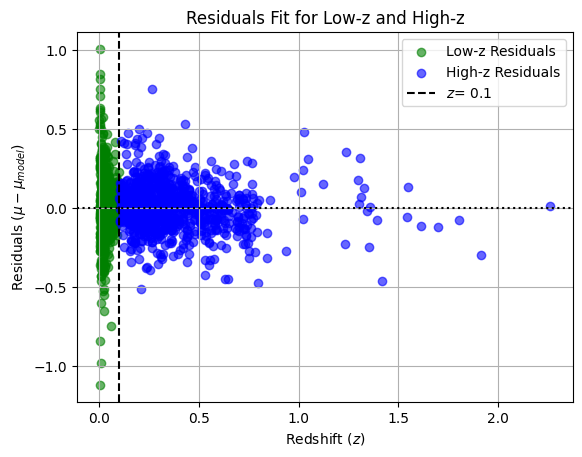

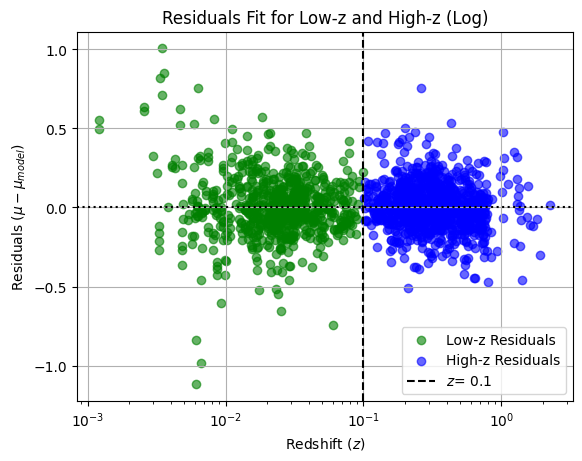

In [23]:
# Plot the residuals for low-z and high-z data

residuals_low = mu_low - mu_model_values_low_fixOm  # Calculate the residuals for low-z
residuals_high = mu_high - mu_model_values_high_fixOm  # Calculate the residuals for high-z
#print("Residuals for Low-z:", residuals_low, "\nResiduals for High-z:",residuals_high) # Print the residuals to verify their contents

plt.figure()
##plt.errorbar(z_low, residuals_low, yerr=mu_err_low, fmt='o', color='blue', ecolor='red', capsize=3, label='Low-z Residuals')  # Plot low-z residuals with error bars
##plt.errorbar(z_high, residuals_high, yerr=mu_err_high, fmt='o', color='green', ecolor='red', capsize=3, label='High-z Residuals')  # Plot high-z residuals with error bars
plt.scatter(z_low, residuals_low, color='green', label='Low-z Residuals', alpha=0.6)  # Plot low-z residuals as points
plt.scatter(z_high, residuals_high, color='blue', label='High-z Residuals', alpha=0.6)  # Plot high-z residuals as points
##plt.plot(z_low, residuals_low, color='blue', label='Low-z Residuals')  # Plot low-z residuals as points
##plt.plot(z_high, residuals_high, color='green', label='High-z Residuals')  # Plot high-z residuals as points
plt.axhline(0, color='black', linestyle=':')  # Add a horizontal line at zero for reference
plt.axvline(0.1, color='black', linestyle='--', label='$z$= 0.1')  # Add a vertical line at zero for reference
plt.title('Residuals Fit for Low-z and High-z')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Residuals ($\mu - \mu_{model}$)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
##plt.errorbar(z_low, residuals_low, yerr=mu_err_low, fmt='o', color='blue', ecolor='red', capsize=3, label='Low-z Residuals')  # Plot low-z residuals with error bars
##plt.errorbar(z_high, residuals_high, yerr=mu_err_high, fmt='o', color='green', ecolor='red', capsize=3, label='High-z Residuals')  # Plot high-z residuals with error bars
plt.scatter(z_low, residuals_low, color='green', label='Low-z Residuals', alpha=0.6)  # Plot low-z residuals as points
plt.scatter(z_high, residuals_high, color='blue', label='High-z Residuals', alpha=0.6)  # Plot high-z residuals as points
##plt.plot(z_low, residuals_low, color='blue', label='Low-z Residuals')  # Plot low-z residuals as points
##plt.plot(z_high, residuals_high, color='green', label='High-z Residuals')  # Plot high-z residuals as points
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.axhline(0, color='black', linestyle=':')  # Add a horizontal line at zero for reference
plt.axvline(0.1, color='black', linestyle='--', label='$z$= 0.1')  # Add a vertical line at zero for reference
plt.title('Residuals Fit for Low-z and High-z (Log)')
plt.xlabel(r"Redshift ($z$)")
plt.ylabel(r"Residuals ($\mu - \mu_{model}$)")
plt.grid(True)
plt.legend()
plt.show()

### Result & Interpretation  
In this section, we present the fitted cosmological parameters, compare them with established measurements, and analyze the implications of the results. Residuals and redshift-dependent behaviors are also discussed.

##### The Hubble Constant ($H_0$)  
From the best-fit to the Pantheon+SH0ES supernovae sample using the ΛCDM model, we obtained:  

For two parameter ($H_0$ and $\Omega_m$ ) full dataset fit:  
$H_0$ = 72.97 ± 0.26 (km/s)/Mpc  
$\Omega_m$ = 0.351 ± 0.019  

This value was estimated by fitting the observed distance modulus ($\mu_{obs}$) to the theoretical prediction from the ΛCDM cosmological model.

#####  Compairing Hubble Constant between SH0ES and Planck18

According to Planck18 (CMB): $H_0$ 67.4 ± 0.5 (km/s)/Mpc  
My estimation: $H_0$ = 72.97 ± 0.26 (km/s)/Mpc  

There is a significant tension of ~ 5.5 (km/s)/Mpc. This reflects the Hubble Tension between early age (CMB) and late age (Supernova) observation.

##### The Age of the Universe  
Estimated age of the universe-    
For full fit ($H_0$ = 72.97 & $\Omega_m$ = 0.351):  $t_0$ = 12.36 Gyr  
For full fit ($H_0$ = 72.97) with fixed $\Omega_m$ (0.3):  $t_0$ = 12.92 Gyr  
The age of the universe $t_0$ decreases as $\Omega_m$ increases. That means the universe expanded more slowly (the universe is yonger).  
The age of the universe $t_0$ icreases as $\Omega_m$ decreases. That means the universe expanded faster (the universe is older than expected).  
So, the age of the Universe is sensitive to the matter density, and this should be taken into account in theoretical models.

##### Difference in Hubble Constant for Low and High Redshift  
Fit for Low-z (z < 0.1) with fixed $\Omega_m$(0.3): H₀ = 73.01 (km/s)/Mpc  
Fit for High-z (z ≥ 0.1) with fixed $\Omega_m$(0.3): H₀ = 73.85 (km/s)/Mpc  
Difference: ~ 0.84 (km/s)/Mpc  

This trend may point to:  
-Local structure effects (e.g., a local underdensity or void)  
-Evolution in supernova properties  
-Limitations of the ΛCDM model itself  

Such a redshift-dependent trend supports the idea that the Hubble tension may not be purely systematic and could hint at new physics.

##### Residuals  

Residual plots generally show random scatter around zero, with larger deviations at very low or very high redshifts. No strong systematic trends were observed, suggesting the ΛCDM model still fits well on average.

However, slight skewness in the residuals may point to:  
-Peculiar velocities at low-z  
-Higher observational uncertainties at high-z  
-Model limitations or calibration differences  

##### Assumption in our Model  
In our case we assumed, flat universe ΛCDM model (Flat: $\Omega_k$=0, cold darkmatter: $\omega$=-1), no evolution.  
If we relax (Flat: $\Omega_k$ $\neq$ 0, cold darkmatter: $\omega$ $\neq$-1) then it alters the distance and redshift relation, changes growth of the structure and expansion rates or reconciles tensions.

##### Expansion History  

The fitted Hubble diagram confirms the accelerating expansion of the Universe. The transition from decelerated to accelerated expansion is visible in the curvature of the plot — linear at low-z, flattening at high-z.

This supports the ΛCDM model and the presence of dark energy. The fact that high-z SN appear dimmer than expected in a matter-only Universe also supports this interpretation.

### Conclusion & Future Work

In this project, we analyzed the Pantheon+SH0ES Type Ia supernova dataset to estimate key cosmological parameters. Using the SH0ES-calibrated distance modulus values and redshift data, we fitted a flat $\Lambda$CDM model and obtained the following results:

The residuals showed no major systematic errors, indicating that the flat $\Lambda$CDM model provides a good fit to the data. However, a noticeable difference in $H_0$ between low- and high-redshift subsamples was observed. This supports the continuing tension between local and early-Universe measurements of $H_0$, possibly pointing to unknown astrophysical effects or the need for new cosmological physics.

This project demonstrates the power of supernovae as cosmological probes and provides insight into current challenges in precision cosmology.



### References & Data Sources

Data Sources:

1. Pantheon+SH0ES Compilation:
Brout, D., et al. The Pantheon+ Analysis: Cosmological Constraints. arXiv:2202.04077
2. Data available at: https://github.com/PantheonPlusSH0ES/DataRelease

Key References:

1. Planck Collaboration (Aghanim et al.). Planck 2018 results. VI. Cosmological parameters. Astronomy & Astrophysics, 641, A6 (2020)

2. Riess, A. G., et al. A Comprehensive Measurement of the Local Value of the Hubble Constant with 1 km/s/Mpc Uncertainty from the SH0ES Team. arXiv:2112.04510

3. Hogg, D. W. Distance measures in cosmology. arXiv:astro-ph/9905116, Weinberg, S. Cosmology, Oxford University Press (2008).

4. Mukhanov, V. Physical Foundations of Cosmology, Cambridge University Press (2005).


